# 👩‍💻 Experiment with Regularization Techniques for Neural Networks

## 📋 Overview
In this lab, you'll apply and evaluate various regularization techniques to improve a neural network's performance on image data. You will work with a baseline model and progressively enhance it using dropout, L2 weight decay, and batch normalization. These techniques are essential for preventing overfitting and ensuring your models generalize well to unseen data - critical skills for any machine learning practitioner.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Implement and evaluate a baseline neural network on an image classification task
- Apply dropout layers to reduce overfitting in neural networks
- Implement weight decay (L2 regularization) to enhance model generalization
- Integrate batch normalization to improve training stability and convergence speed
- Compare and analyze the effects of different regularization techniques on model performance

## 🚀 Starting Point
Access the starter code by creating a new Python notebook in your preferred environment (Colab, Jupyter, etc.).

Required tools/setup:

- Python 3.6+
- PyTorch
- Matplotlib
- Numpy

Make sure you've completed previous labs on neural networks and are familiar with basic model training.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- 1. Device Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 2. Data Loading and Preprocessing ---
# MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Standard normalization for MNIST
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

Using device: cuda


## Task 1: Create and Train a Baseline Model
**Context:** As a first step in understanding the effects of regularization, you need to establish a baseline model to serve as a reference point for comparison.

**Steps:**

1. Define a simple CNN model class with convolutional layers followed by fully connected layers

    - Use `nn.Conv2d` for convolutional layers with appropriate kernel sizes
    - Add `nn.ReLU` activations after each layer
    - Include fully connected layers using `nn.Linear`
    - What architecture complexity is appropriate for this task?

2. Instantiate the baseline model, loss function, and optimizer

    - Use `CrossEntropyLoss()` for classification tasks
    - Consider using `optim.SGD` or `ptim.Adam` for optimization
    - What learning rate would be appropriate?

3. Train the model and evaluate performance

    - Use the provided `train()` and `evaluate()` functions
    - Save the training and testing metrics for comparison

4. Plot the training and validation loss curves

    - How can you determine if the model is overfitting?


--- Training Baseline Model ---
Epoch 1/10, Train Loss: 0.1331
Epoch 2/10, Train Loss: 0.0408
Epoch 3/10, Train Loss: 0.0286
Epoch 4/10, Train Loss: 0.0213
Epoch 5/10, Train Loss: 0.0164
Epoch 6/10, Train Loss: 0.0139
Epoch 7/10, Train Loss: 0.0112
Epoch 8/10, Train Loss: 0.0095
Epoch 9/10, Train Loss: 0.0070
Epoch 10/10, Train Loss: 0.0063
Test Loss: 0.0321, Accuracy: 99.09%


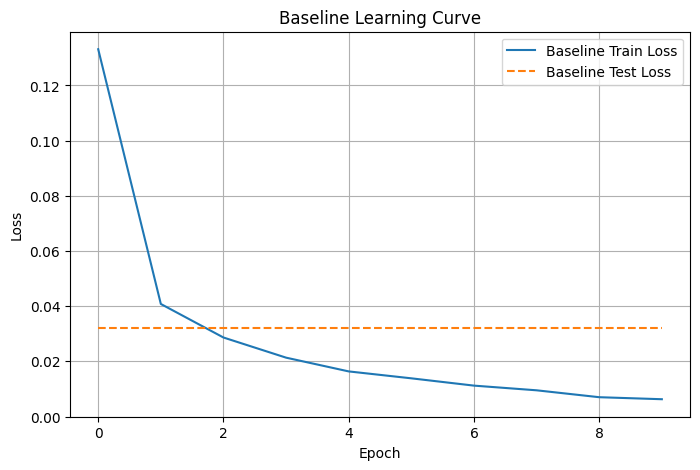

In [2]:
# # Your baseline model implementation
# class BaselineModel(nn.Module):
#     def __init__(self):
#         super(BaselineModel, self).__init__()
#         # TODO: Define layers for your baseline model
#         # Convolutional layers
        
#         # Fully connected layers
        
#     def forward(self, x):
#         # TODO: Implement forward pass
        
#         return x

# Task 1: Create and Train a Baseline Model ---
    
# Define a simple CNN model class
class BaselineModel(nn.Module):
    def __init__(self):
        super(BaselineModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# TODO: Instantiate model, define loss function and optimizer
def train(model, train_loader, optimizer, criterion, epochs):
    model.train()
    train_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}")
    return train_losses

def evaluate(model, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%')
    return test_loss, accuracy

# TODO: Train the model and track metrics
# Train and evaluate the baseline model
baseline_model = BaselineModel().to(device)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("\n--- Training Baseline Model ---")
baseline_train_losses = train(baseline_model, train_loader, baseline_optimizer, criterion, epochs=10)
baseline_test_loss, baseline_accuracy = evaluate(baseline_model, test_loader, criterion)

# TODO: Evaluate the model on test data
# Plot learning curve for the baseline model
def plot_learning_curves(train_losses, test_loss, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label=f'{model_name} Train Loss')
    plt.plot([test_loss] * len(train_losses), linestyle='--', label=f'{model_name} Test Loss')
    plt.title(f'{model_name} Learning Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curves(baseline_train_losses, baseline_test_loss, "Baseline")

**💡 Tip:** Keep your baseline model relatively simple (2-3 convolutional layers followed by 1-2 fully connected layers) to better observe the effects of regularization techniques.

## Task 2: Implement Dropout
**Context:** Dropout is a powerful technique that prevents co-adaptation of neurons by randomly setting a fraction of inputs to zero during training, which helps reduce overfitting.

**Steps:**

1. Create a new model class that incorporates dropout layers

    - Add `nn.Dropout` layers after fully connected layers
    - Try a moderate dropout rate (0.2-0.5)
    - How might placement of dropout layers affect model performance?

2. Train the model with dropout and evaluate
    
    - Use the same training parameters as the baseline for fair comparison
    - Pay attention to differences in training time and convergence

3. Compare the dropout model's performance with the baseline

    - Are there notable differences in train vs test loss curves?
    - How does dropout affect the gap between training and validation performance?


--- Training Dropout Model ---
Epoch 1/10, Train Loss: 0.2177
Epoch 2/10, Train Loss: 0.0794
Epoch 3/10, Train Loss: 0.0594
Epoch 4/10, Train Loss: 0.0488
Epoch 5/10, Train Loss: 0.0422
Epoch 6/10, Train Loss: 0.0362
Epoch 7/10, Train Loss: 0.0320
Epoch 8/10, Train Loss: 0.0286
Epoch 9/10, Train Loss: 0.0252
Epoch 10/10, Train Loss: 0.0199
Test Loss: 0.0224, Accuracy: 99.30%


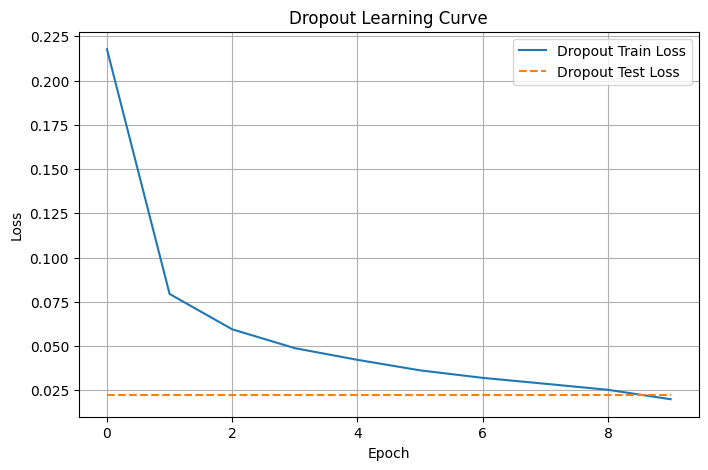

In [3]:
# Your dropout model implementation
# class DropoutModel(nn.Module):
#     def __init__(self, dropout_rate=0.5):
#         super(DropoutModel, self).__init__()
#         # TODO: Define layers including dropout
#         # Convolutional layers
        
#         # Dropout + Fully connected layers
        
#     def forward(self, x):
#         # TODO: Implement forward pass with dropout
        
#         return x

# Define CNN model with dropout
class DropoutModel(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(DropoutModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        return x

# TODO: Instantiate dropout model, define loss function and optimizer
dropout_model = DropoutModel(dropout_rate=0.5).to(device)
dropout_optimizer = optim.Adam(dropout_model.parameters(), lr=0.001)

# TODO: Train the model and track metrics
print("\n--- Training Dropout Model ---")
dropout_train_losses = train(dropout_model, train_loader, dropout_optimizer, criterion, epochs=10)

# TODO: Evaluate the model on test data
dropout_test_loss, dropout_accuracy = evaluate(dropout_model, test_loader, criterion)

# TODO: Compare with baseline
plot_learning_curves(dropout_train_losses, dropout_test_loss, "Dropout")

**💡 Tip:** Experiment with different dropout rates to find the optimal balance between regularization and model capacity. Remember that dropout is only active during training, not during evaluation.

## Task 3: Apply Weight Decay (L2 Regularization)
**Context:** Weight decay adds a penalty to the loss function proportional to the squared magnitude of the weights, encouraging the model to learn smaller weights and potentially generalize better.

**Steps:**

1. Create a new model with the same architecture as the baseline

2. Configure the optimizer with weight decay

    - Add the `weight_decay` parameter to your optimizer (try values like 1e-4 or 1e-5)
    - How does the choice of weight decay value relate to the learning rate?

3. Train the model with weight decay and evaluate

    - What differences do you observe in the weights distributions?
    - How does convergence speed compare to the baseline?

4. Compare performance with previous models

    - Does weight decay effectively reduce overfitting?
    - How does it compare to dropout in terms of generalization?


--- Training Weight Decay Model ---
Epoch 1/10, Train Loss: 0.1360
Epoch 2/10, Train Loss: 0.0445
Epoch 3/10, Train Loss: 0.0309
Epoch 4/10, Train Loss: 0.0244
Epoch 5/10, Train Loss: 0.0204
Epoch 6/10, Train Loss: 0.0163
Epoch 7/10, Train Loss: 0.0142
Epoch 8/10, Train Loss: 0.0130
Epoch 9/10, Train Loss: 0.0122
Epoch 10/10, Train Loss: 0.0112
Test Loss: 0.0296, Accuracy: 99.13%


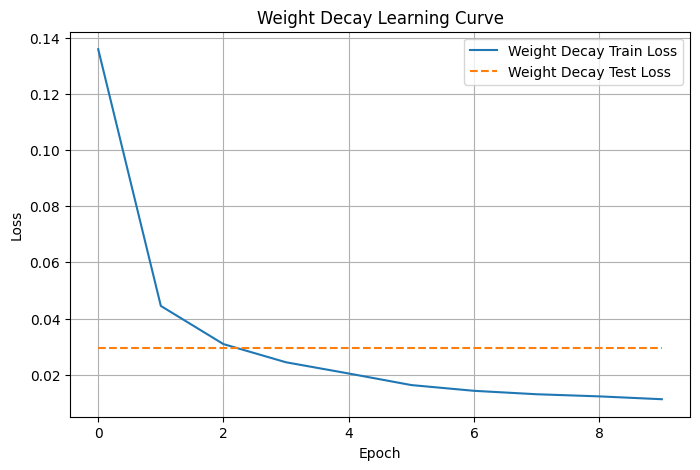

In [4]:
# Your weight decay implementation uses the same model architecture as baseline
# but with weight decay in the optimizer

# TODO: Instantiate model with same architecture as baseline
weightdecay_model = BaselineModel().to(device)

# TODO: Define loss function and optimizer with weight decay
weightdecay_optimizer = optim.Adam(weightdecay_model.parameters(), lr=0.001, weight_decay=1e-4)

# TODO: Train the model and track metrics
print("\n--- Training Weight Decay Model ---")
weightdecay_train_losses = train(weightdecay_model, train_loader, weightdecay_optimizer, criterion, epochs=10)

# TODO: Evaluate the model on test data
weightdecay_test_loss, weightdecay_accuracy = evaluate(weightdecay_model, test_loader, criterion)

# TODO: Compare with baseline and dropout models
plot_learning_curves(weightdecay_train_losses, weightdecay_test_loss, "Weight Decay")

**💡 Tip:** Start with a small weight decay value (1e-5) and gradually increase it if needed. Too large a value can impede learning.

## Task 4: Implement Batch Normalization
**Context:** Batch normalization normalizes the inputs of each layer, which can stabilize and accelerate training by reducing internal covariate shift.

**Steps:**

1. Create a new model that incorporates batch normalization

    - Add `nn.BatchNorm2d` after convolutional layers but before activations
    - Add `nn.BatchNorm1d` for fully connected layers
    - Why might the order of batch norm and activation functions matter?

2. Train the model with batch normalization and evaluate

    - Try using a slightly higher learning rate than before
    - How does batch normalization affect training stability?

3. Compare training speed and final performance with previous models

    - Does batch normalization accelerate convergence?
    - How does it affect the model's generalization ability?

4. Visualize and compare learning curves for all models

    - Which regularization technique had the most significant impact?


--- Training BatchNorm Model ---
Epoch 1/10, Train Loss: 0.0963
Epoch 2/10, Train Loss: 0.0363
Epoch 3/10, Train Loss: 0.0225
Epoch 4/10, Train Loss: 0.0180
Epoch 5/10, Train Loss: 0.0131
Epoch 6/10, Train Loss: 0.0121
Epoch 7/10, Train Loss: 0.0098
Epoch 8/10, Train Loss: 0.0069
Epoch 9/10, Train Loss: 0.0061
Epoch 10/10, Train Loss: 0.0049
Test Loss: 0.0299, Accuracy: 99.17%

--- Final Test Accuracies ---
Baseline: 99.09%
Dropout: 99.30%
Weight Decay: 99.13%
BatchNorm: 99.17%


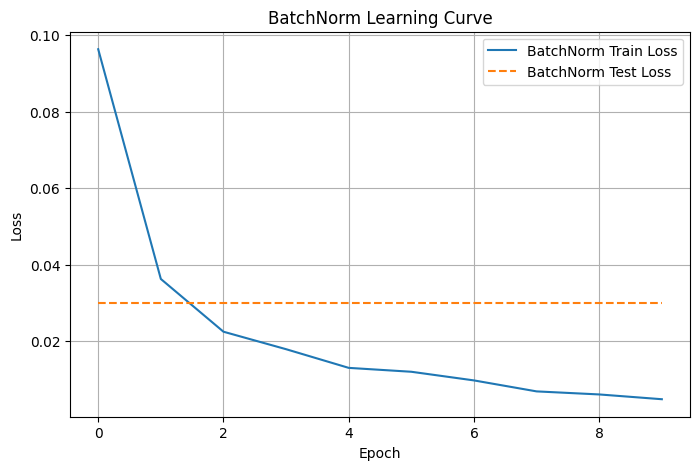

In [5]:
# Your batch normalization model implementation
# class BatchNormModel(nn.Module):
#     def __init__(self):
#         super(BatchNormModel, self).__init__()
#         # TODO: Define layers with batch normalization
#         # Conv > BatchNorm > ReLU sequences
        
#         # Fully connected layers with batch norm
        
#     def forward(self, x):
#         # TODO: Implement forward pass with batch normalization
        
#         return x

# Define CNN model with batch normalization
class BatchNormModel(nn.Module):
    def __init__(self):
        super(BatchNormModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

# TODO: Instantiate batch norm model, define loss function and optimizer
batchnorm_model = BatchNormModel().to(device)
batchnorm_optimizer = optim.Adam(batchnorm_model.parameters(), lr=0.0015)

# TODO: Train the model and track metrics
print("\n--- Training BatchNorm Model ---")
batchnorm_train_losses = train(batchnorm_model, train_loader, batchnorm_optimizer, criterion, epochs=10)

# TODO: Evaluate the model on test data
batchnorm_test_loss, batchnorm_accuracy = evaluate(batchnorm_model, test_loader, criterion)

# TODO: Compare with all previous models
# --- Final Comparison of All Models ---
print("\n--- Final Test Accuracies ---")
print(f"Baseline: {baseline_accuracy:.2f}%")
print(f"Dropout: {dropout_accuracy:.2f}%")
print(f"Weight Decay: {weightdecay_accuracy:.2f}%")
print(f"BatchNorm: {batchnorm_accuracy:.2f}%")

# TODO: Plot comparative learning curves
plot_learning_curves(batchnorm_train_losses, batchnorm_test_loss, "BatchNorm")

**💡 Tip:** Batch normalization often allows for higher learning rates and can significantly accelerate training. Pay attention to how the model behaves in early training epochs.

**⚙️ Test Your Work:**
For each model, run the following tests:

- Evaluate on the test dataset and record accuracy

    - Baseline model should achieve at least 95% accuracy
    - Regularized models should maintain or improve this accuracy

- For each model, calculate and compare:

    - Final training loss
    - Final test loss
    - Gap between training and test loss (indicator of overfitting)
    - Training time per epoch

## ✅ Success Checklist
- Successfully implemented and trained a baseline CNN model
- Applied dropout regularization and analyzed its impact
- Implemented weight decay and evaluated its effect on generalization
- Integrated batch normalization and assessed training stability
- Compared all approaches using well-formatted learning curves
- Identified which regularization technique worked best for this task
- Model runs without errors and achieves reasonable accuracy (>95% on MNIST)

## 🔍 Common Issues & Solutions
**Problem:** Model shows signs of severe overfitting (large gap between training and test loss) **Solution:** Increase regularization strength (higher dropout rate or weight decay parameter).

**Problem:** Model convergence is too slow **Solution:** Check learning rate, consider using batch normalization, or implement learning rate scheduling.

**Problem:** Loss becomes unstable or NaN **Solution:** Reduce learning rate, check for proper initialization, or review batch normalization implementation.

## 🔑 Key Points
- Dropout randomly deactivates neurons during training, forcing the network to learn redundant representations
- Weight decay penalizes large weights, encouraging the model to find simpler solutions
- Batch normalization stabilizes training by normalizing layer inputs, often allowing faster convergence
- The choice of regularization technique depends on the specific dataset and model architecture

## 💻 Reference Solution

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
# Task 1: Create and Train a Baseline Model ---
    
# Define a simple CNN model class
class BaselineModel(nn.Module):
    def __init__(self):
        super(BaselineModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Define training and evaluation functions

def train(model, train_loader, optimizer, criterion, epochs):
    model.train()
    train_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}")
    return train_losses

def evaluate(model, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%')
    return test_loss, accuracy

# Train and evaluate the baseline model
baseline_model = BaselineModel().to(device)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("\n--- Training Baseline Model ---")
baseline_train_losses = train(baseline_model, train_loader, baseline_optimizer, criterion, epochs=10)
baseline_test_loss, baseline_accuracy = evaluate(baseline_model, test_loader, criterion)

# Plot learning curve for the baseline model
def plot_learning_curves(train_losses, test_loss, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label=f'{model_name} Train Loss')
    plt.plot([test_loss] * len(train_losses), linestyle='--', label=f'{model_name} Test Loss')
    plt.title(f'{model_name} Learning Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curves(baseline_train_losses, baseline_test_loss, "Baseline")


# Task 2: Implement Dropout 

# Define CNN model with dropout
class DropoutModel(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(DropoutModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        return x

# Train and evaluate dropout model
dropout_model = DropoutModel(dropout_rate=0.5).to(device)
dropout_optimizer = optim.Adam(dropout_model.parameters(), lr=0.001)

print("\n--- Training Dropout Model ---")
dropout_train_losses = train(dropout_model, train_loader, dropout_optimizer, criterion, epochs=10)
dropout_test_loss, dropout_accuracy = evaluate(dropout_model, test_loader, criterion)

plot_learning_curves(dropout_train_losses, dropout_test_loss, "Dropout")


# Task 3: Apply Weight Decay 

# Instantiate baseline model architecture again
weightdecay_model = BaselineModel().to(device)
# Define optimizer with weight decay
weightdecay_optimizer = optim.Adam(weightdecay_model.parameters(), lr=0.001, weight_decay=1e-4)

# Train and evaluate model with weight decay
print("\n--- Training Weight Decay Model ---")
weightdecay_train_losses = train(weightdecay_model, train_loader, weightdecay_optimizer, criterion, epochs=10)
weightdecay_test_loss, weightdecay_accuracy = evaluate(weightdecay_model, test_loader, criterion)

plot_learning_curves(weightdecay_train_losses, weightdecay_test_loss, "Weight Decay")


# --- Task 4: Implement Batch Normalization ---

# Define CNN model with batch normalization
class BatchNormModel(nn.Module):
    def __init__(self):
        super(BatchNormModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

# Train and evaluate batch normalization model
batchnorm_model = BatchNormModel().to(device)
batchnorm_optimizer = optim.Adam(batchnorm_model.parameters(), lr=0.0015)

print("\n--- Training BatchNorm Model ---")
batchnorm_train_losses = train(batchnorm_model, train_loader, batchnorm_optimizer, criterion, epochs=10)
batchnorm_test_loss, batchnorm_accuracy = evaluate(batchnorm_model, test_loader, criterion)

plot_learning_curves(batchnorm_train_losses, batchnorm_test_loss, "BatchNorm")
    
# --- Final Comparison of All Models ---
print("\n--- Final Test Accuracies ---")
print(f"Baseline: {baseline_accuracy:.2f}%")
print(f"Dropout: {dropout_accuracy:.2f}%")
print(f"Weight Decay: {weightdecay_accuracy:.2f}%")
print(f"BatchNorm: {batchnorm_accuracy:.2f}%")
```    